# 01 — Tensors & Operations: The Building Blocks of PyTorch

**Goal:** Understand what a tensor is, how to create and manipulate them, and why they are the foundation of every ML model you will build.

---

> **ContextQuant connection:** Every piece of data in this project — stock prices, RSI values, BERT embeddings — will live inside tensors before being fed to a neural network.

**What you'll learn in this notebook:**
1. Install & verify the environment
2. Create tensors many different ways
3. Understand shapes, dtypes, and devices
4. Perform arithmetic, indexing, and reshaping
5. Interop with NumPy
6. Build and train a tiny neural network end-to-end


## Section 1 — Install & Import Core Libraries

Before anything, make sure your environment is active (`conda activate context-quant`).

Then verify that everything is importable and PyTorch can see your hardware.


In [1]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"NumPy    : {np.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")

# Pick the best available device — we'll use this throughout the notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")


Python   : 3.11.14
PyTorch  : 2.5.1
NumPy    : 2.4.2
CUDA available : False

Using device: cpu


## Section 2 — What is a Tensor?

A **tensor** is simply an n-dimensional array of numbers — just like a NumPy array, but:
- It can live on a **GPU** for fast parallel computation
- It tracks **gradients** automatically (the magic behind training)

| Dimensions | Name | Example |
|------------|------|---------|
| 0-D | scalar | a single closing price: `tensor(182.5)` |
| 1-D | vector | one day of features: `[open, high, low, close, volume]` |
| 2-D | matrix | 60 days × 5 features (one training sample) |
| 3-D | batch  | 32 samples × 60 days × 5 features (a training batch) |


In [3]:
# ── 2a. Creating tensors ─────────────────────────────────────────────────────

# From a Python list (imagine one day of OHLCV data)
ohlcv_day = torch.tensor([182.5, 185.3, 181.0, 184.7, 95_000_000.0])
print("From list       :", ohlcv_day)
print("Shape           :", ohlcv_day.shape)   # torch.Size([5])
print("Dtype           :", ohlcv_day.dtype)   # float32 by default

# Common factory functions
zeros  = torch.zeros(3, 5)        # 3 rows, 5 cols — all zeros
ones   = torch.ones(3, 5)         # all ones
random = torch.rand(3, 5)         # random values in [0, 1)

print("\ntorch.zeros(3,5):\n", zeros)
print("\ntorch.rand(3,5):\n",  random)

# 3-D: simulate a batch of 4 samples, each 60 days × 5 features
batch = torch.rand(4, 60, 5)
print(f"\nBatch tensor shape: {batch.shape}")  # ← the shape you'll see constantly


From list       : tensor([1.8250e+02, 1.8530e+02, 1.8100e+02, 1.8470e+02, 9.5000e+07])
Shape           : torch.Size([5])
Dtype           : torch.float32

torch.zeros(3,5):
 tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

torch.rand(3,5):
 tensor([[0.2111, 0.1966, 0.3903, 0.4016, 0.5841],
        [0.2010, 0.4068, 0.2866, 0.8313, 0.0169],
        [0.2865, 0.5765, 0.7232, 0.2452, 0.4932]])

Batch tensor shape: torch.Size([4, 60, 5])


In [4]:
# ── 2b. Shapes, reshaping, and indexing ──────────────────────────────────────

prices = torch.tensor([
    [100.0, 102.5, 101.0],   # Day 1: open, high, close
    [101.0, 103.2, 102.8],   # Day 2
    [102.8, 104.1, 103.5],   # Day 3
])

print("Shape  :", prices.shape)          # (3, 3)
print("Rows   :", prices.shape[0])       # 3 days
print("Cols   :", prices.shape[1])       # 3 features

# Indexing — just like NumPy
print("\nDay 2 (all features):", prices[1])          # row index 1
print("Close prices        :", prices[:, 2])        # all rows, col 2

# Reshape — crucial when feeding data into layers
flat = prices.reshape(-1)               # flatten to 1-D (9 elements)
print("\nFlattened :", flat)

back = flat.reshape(3, 3)               # back to (3, 3)
print("Restored  :\n", back)


Shape  : torch.Size([3, 3])
Rows   : 3
Cols   : 3

Day 2 (all features): tensor([101.0000, 103.2000, 102.8000])
Close prices        : tensor([101.0000, 102.8000, 103.5000])

Flattened : tensor([100.0000, 102.5000, 101.0000, 101.0000, 103.2000, 102.8000, 102.8000,
        104.1000, 103.5000])
Restored  :
 tensor([[100.0000, 102.5000, 101.0000],
        [101.0000, 103.2000, 102.8000],
        [102.8000, 104.1000, 103.5000]])


## Section 3 — Tensor Operations & Math

PyTorch operators mirror NumPy almost exactly. The key addition is `torch.matmul()` — matrix multiplication is the core computation of every neural network layer.


In [5]:
a = torch.tensor([100.0, 110.0, 120.0])   # 3 closing prices
b = torch.tensor([98.0,  108.0, 121.0])   # previous day closes

# Element-wise arithmetic
print("Returns (a - b)  :", a - b)
print("Percent change   :", (a - b) / b * 100)
print("Element multiply :", a * b)

# Aggregate operations
print("\nMean close  :", a.mean().item())   # .item() extracts a Python float
print("Max close   :", a.max().item())
print("Std dev     :", a.std().item())

# Matrix multiplication — the heart of neural network forward passes
# Imagine: input features (1 sample, 5 features) × weight matrix (5 → 3)
x = torch.rand(1, 5)      # one data point with 5 features
W = torch.rand(5, 3)      # weight matrix (5 inputs → 3 outputs)
out = torch.matmul(x, W)  # result shape: (1, 3)
print(f"\nMatrix mul: ({x.shape}) @ ({W.shape}) = {out.shape}")
print("Output     :", out)

# In-place operation (modifies tensor directly — note the trailing _)
a.add_(1.0)   # add 1 to every element in-place
print("\na after add_(1.0):", a)


Returns (a - b)  : tensor([ 2.,  2., -1.])
Percent change   : tensor([ 2.0408,  1.8519, -0.8264])
Element multiply : tensor([ 9800., 11880., 14520.])

Mean close  : 110.0
Max close   : 120.0
Std dev     : 10.0

Matrix mul: (torch.Size([1, 5])) @ (torch.Size([5, 3])) = torch.Size([1, 3])
Output     : tensor([[1.0921, 0.7719, 1.1712]])

a after add_(1.0): tensor([101., 111., 121.])


## Section 4 — NumPy & PyTorch Interop

You will constantly move data between pandas/NumPy and PyTorch. Important gotcha: when a tensor lives on CPU, `.numpy()` returns a **view** — they share the same memory.


In [6]:
import numpy as np

# NumPy → PyTorch
np_prices = np.array([180.5, 182.1, 183.4, 181.9], dtype=np.float32)
t = torch.from_numpy(np_prices)
print("NumPy  → Tensor:", t, t.dtype)

# PyTorch → NumPy (shared memory — both point to the same data on CPU)
t2 = torch.tensor([1.0, 2.0, 3.0])
np_view = t2.numpy()
t2 += 10                               # mutate the tensor …
print("\nAfter mutating tensor, numpy array also changed:", np_view)  # ← same data!

# Safe copy (avoids shared-memory surprises)
safe_np = t2.detach().clone().numpy()
t2 += 100
print("Safe copy is unchanged:", safe_np)

# Moving to / from GPU
# t_gpu = t.to("cuda")          # uncomment if you have a GPU
# t_cpu = t_gpu.cpu().numpy()   # must move back to CPU before .numpy()
print("\nTo move to GPU: tensor.to('cuda')  or  tensor.to(device)")


NumPy  → Tensor: tensor([180.5000, 182.1000, 183.4000, 181.9000]) torch.float32

After mutating tensor, numpy array also changed: [11. 12. 13.]
Safe copy is unchanged: [11. 12. 13.]

To move to GPU: tensor.to('cuda')  or  tensor.to(device)


## Section 5 — Dataset & DataLoader

In ContextQuant, you'll have thousands of stock windows as training samples. `Dataset` + `DataLoader` handles batching, shuffling, and parallel loading so your training loop stays clean.


In [7]:
from torch.utils.data import Dataset, DataLoader

class StockWindowDataset(Dataset):
    """
    Synthetic dataset: each sample is a (window, label) pair.
    window : (seq_len, n_features) — e.g., 60 days × 5 OHLCV features
    label  : 0 = down, 1 = up   (next-day direction)
    """
    def __init__(self, n_samples: int = 200, seq_len: int = 60, n_features: int = 5):
        self.X = torch.rand(n_samples, seq_len, n_features)  # random price windows
        self.y = torch.randint(0, 2, (n_samples,))           # random binary labels

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = StockWindowDataset(n_samples=200)
loader  = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"Total samples : {len(dataset)}")
print(f"Batches/epoch : {len(loader)}")

# Peek at the first batch
X_batch, y_batch = next(iter(loader))
print(f"\nX_batch shape : {X_batch.shape}")   # (32, 60, 5)
print(f"y_batch shape : {y_batch.shape}")    # (32,)
print(f"Labels sample : {y_batch[:8]}")


Total samples : 200
Batches/epoch : 7

X_batch shape : torch.Size([32, 60, 5])
y_batch shape : torch.Size([32])
Labels sample : tensor([0, 0, 1, 1, 1, 1, 1, 1])


## Section 6 — Build Your First Neural Network

We'll build a simple feedforward classifier. This is a "flat" version of what will eventually become the Fusion Layer in ContextQuant — it takes some feature vector and outputs a class probability.


In [8]:
import torch.nn as nn

class SimpleClassifier(nn.Module):
    """
    A 3-layer feedforward network.
    input_dim  : number of features per sample
    hidden_dim : width of the hidden layers
    n_classes  : number of output categories (2 for up/down, 5 for Strong Sell → Strong Buy)
    """
    def __init__(self, input_dim: int, hidden_dim: int, n_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),   # fully-connected layer
            nn.ReLU(),                           # activation function
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_classes),    # output logits (no activation yet)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# The DataLoader produces batches of shape (32, 60, 5)
# We flatten each window to a 1-D vector before passing to this simple net
INPUT_DIM  = 60 * 5   # flatten window
HIDDEN_DIM = 128
N_CLASSES  = 2        # binary: up / down

model = SimpleClassifier(INPUT_DIM, HIDDEN_DIM, N_CLASSES).to(device)
print(model)

# Quick sanity check
dummy_input = torch.rand(8, INPUT_DIM).to(device)   # batch of 8
logits = model(dummy_input)
print(f"\nInput  : {dummy_input.shape}")
print(f"Output : {logits.shape}")   # (8, 2) — one score per class per sample


SimpleClassifier(
  (net): Sequential(
    (0): Linear(in_features=300, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

Input  : torch.Size([8, 300])
Output : torch.Size([8, 2])


## Section 7 — The Training Loop

The training loop is the **core ritual** of deep learning. Every model — from this simple classifier to the full ContextQuant Fusion Net — uses exactly this pattern:

```
for each epoch:
    for each batch:
        1. optimizer.zero_grad()   ← clear old gradients
        2. output = model(input)   ← forward pass
        3. loss = criterion(output, target)
        4. loss.backward()         ← compute gradients
        5. optimizer.step()        ← update weights
```


Epoch  1/10  |  Loss: 0.7120
Epoch  2/10  |  Loss: 0.6845
Epoch  3/10  |  Loss: 0.6840
Epoch  4/10  |  Loss: 0.6754
Epoch  5/10  |  Loss: 0.6743
Epoch  6/10  |  Loss: 0.6567
Epoch  7/10  |  Loss: 0.6378
Epoch  8/10  |  Loss: 0.6097
Epoch  9/10  |  Loss: 0.5699
Epoch 10/10  |  Loss: 0.5335


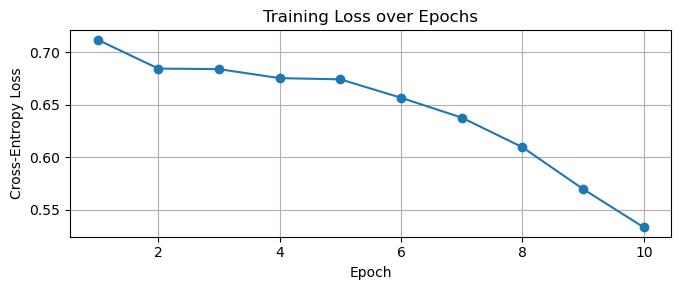

In [10]:
import torch.optim as optim

# ── Setup ─────────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()                    # for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Adam is a great default

# Split dataset 80/20 train/val
n_total = len(dataset)
n_train = int(0.8 * n_total)
train_set, val_set = torch.utils.data.random_split(dataset, [n_train, n_total - n_train])
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)

# ── Training loop ─────────────────────────────────────────────────────────────
EPOCHS     = 10
train_losses = []

for epoch in range(EPOCHS):
    model.train()          # put model in training mode
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_flat = X_batch.reshape(X_batch.size(0), -1).to(device)  # (B, 300)
        y_batch = y_batch.to(device)

        # ── The 5-step ritual ────────────────────────────────────────────────
        optimizer.zero_grad()                  # 1. clear gradients
        logits = model(X_flat)                 # 2. forward pass
        loss = criterion(logits, y_batch)      # 3. compute loss
        loss.backward()                        # 4. backprop
        optimizer.step()                       # 5. update weights
        # ─────────────────────────────────────────────────────────────────────

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:>2}/{EPOCHS}  |  Loss: {avg_loss:.4f}")

# Plot training loss
plt.figure(figsize=(7, 3))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


## Section 8 — Evaluate the Model

Two rules during evaluation:
1. `model.eval()` — disables dropout & batch-norm training behaviour
2. `torch.no_grad()` — tells PyTorch not to build the computational graph (saves memory & speeds things up)


In [11]:
model.eval()   # switch to eval mode

correct = 0
total   = 0

with torch.no_grad():   # no gradient tracking needed during inference
    for X_batch, y_batch in val_loader:
        X_flat  = X_batch.reshape(X_batch.size(0), -1).to(device)
        y_batch = y_batch.to(device)

        logits     = model(X_flat)
        predicted  = logits.argmax(dim=1)   # pick the class with highest score
        correct   += (predicted == y_batch).sum().item()
        total     += y_batch.size(0)

accuracy = correct / total * 100
print(f"Validation Accuracy: {accuracy:.1f}%  ({correct}/{total} correct)")
print()
print("NOTE: ~50% accuracy is expected here — the data is random!")
print("      Real accuracy comes from meaningful features (OHLCV, indicators, news).")
print("      That's what the rest of the notebooks build toward.")


Validation Accuracy: 47.5%  (19/40 correct)

NOTE: ~50% accuracy is expected here — the data is random!
      Real accuracy comes from meaningful features (OHLCV, indicators, news).
      That's what the rest of the notebooks build toward.


---

## Summary — What You Just Learned

| Concept | One-liner |
|---------|-----------|
| Tensor | n-dimensional array that can live on GPU and track gradients |
| `.shape` | Always check this — wrong shapes are the #1 bug in DL |
| `torch.matmul` | The core op of every neural network forward pass |
| `Dataset` + `DataLoader` | Clean way to feed data to a training loop |
| `nn.Module` | Base class for every model — define layers in `__init__`, logic in `forward` |
| Training loop | zero_grad → forward → loss → backward → step |
| `model.eval()` + `no_grad()` | Always use during validation/inference |

## What's Next

**Notebook 2:** `02_autograd_and_gradients.ipynb`
Understand *why* the training loop works — computational graphs, `.backward()`, and how PyTorch figures out which direction to nudge the weights.

**Notebook 3:** `03_training_loop_from_scratch.ipynb`
Build a training loop by hand without any helper code, to make the internals completely clear.
